# CARINA II

Discovered by the Magellanic Satellites Survey (MagLiteS; [Torrealba et al. 2018](https://doi.org/10.1093/mnras/sty170)), Carina II (CarII) is an UFD galaxy located at a heliocentric distance of $\approx$ 37 kpc. 
It forms an intriguing pair with Carina III -- separated by only $18$ arcmin -- and contributes, alongside other DECam discoveries, to an anisotropic cloud of satellites near the Magellanic Clouds. 
Car~II is characterised by an old, metal-poor population, an absolute magnitude of $M_V \approx -4.5$ mag, and a half-light radius of $\approx 90$ pc. 
Its classification as a UFD is further supported by the small population of detected RRLs, with three consistent with its distance.

## Libraries

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

from astropy.io import ascii, fits
from astropy.visualization import ZScaleInterval, ImageNormalize
from astropy.io.votable import parse, parse_single_table
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table, join

from shapely.geometry import Point, Polygon

import csv

import pandas as pd

from scipy.stats import norm, lognorm, expon, gamma

from statistics import mode

import seaborn as sns

from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

import warnings
warnings.filterwarnings('ignore')

import matplotlib.colors as mcolors

## Joint Proper Motions Histograms

In [2]:
def scatter_hist(x, y, x_rr, y_rr, ax, ax_histx, ax_histy, center_pm, err_pm):
    
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    
    ax.set_xlim(-20,20)
    ax.set_ylim(-20,20)
    ax.tick_params(labelsize=14)
    ax.set_xlabel(r'pmra [mas yr$^{-1}$]', fontsize=14)
    ax.set_ylabel(r'pmdec [mas yr$^{-1}$]', fontsize=14)
    
    ax.scatter(x, y, marker='o', s=10, label=r'Sources in 6$r_h$', color='lightgrey')
    ax.scatter(x_rr, y_rr, marker='o', edgecolor='k', s=100, label=r'RR Lyrae Variables', color='gold', zorder=2)

    ax_histx.set_ylim(0,1)
    ax_histy.set_xlim(0,1)
    ax_histx.tick_params(labelsize=14)
    ax_histy.tick_params(labelsize=14)
    ax_histx.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax_histy.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax_histx.yaxis.set_major_locator(mticker.MaxNLocator(nbins=3))
    ax_histy.xaxis.set_major_locator(mticker.MaxNLocator(nbins=3))
    
    ax_histx.hist(x, bins=len(x), density=True, color='grey', alpha=0.5, label='Sources in 6$r_h$')
    ax_histy.hist(y, bins=len(y), density=True, color='grey', alpha=0.5, label='Sources in 6$r_h$', orientation='horizontal')
    
    ax_histx.hist(x_rr, bins=len(x_rr), density=True, color='gold', alpha=0.8, label='RR Lyrae Variables')
    ax_histy.hist(y_rr, bins=len(y_rr), density=True, color='gold', alpha=0.8, label='RR Lyrae Variables', orientation='horizontal')
    
    ax_histx.plot([center_pm[0],center_pm[0]], [0,1], c='white', linewidth=5)
    ax_histy.plot([0,1], [center_pm[1],center_pm[1]], c='white', linewidth=5)
    ax_histx.plot([center_pm[0],center_pm[0]], [0,1], c='deepskyblue', linewidth=2, label=r'$\mu_{pmra}$=' + '{:.3f}'.format(center_pm[0]) + '\n' + r'$\sigma_{pmra}$=' + '{:.3f}'.format(err_pm[0]))
    ax_histy.plot([0,1], [center_pm[1],center_pm[1]], c='deepskyblue', linewidth=2, label=r'$\mu_{pmdec}$=' + '{:.3f}'.format(center_pm[1]) + '\n' + r'$\sigma_{pmdec}$=' + '{:.3f}'.format(err_pm[1]))
    
    ax_histx.axvspan(center_pm[0] - 3*err_pm[0], center_pm[0] + 3*err_pm[0], alpha=0.1, color='cyan', zorder=1)
    ax_histy.axhspan(center_pm[1] - 3*err_pm[1], center_pm[1] + 3*err_pm[1], alpha=0.1, color='cyan', zorder=1)
    
    ax_histx.legend(loc=1, fontsize=14, framealpha=0.95)
    ax_histy.legend(loc=1, fontsize=14, framealpha=0.95)

## Wesenheit Relation for RR Lyrae ([Garofalo et al. 2022](https://doi.org/10.1093/mnras/stac735))

In [3]:
## Garofalo et al. 2022, pag. 14

def pw(period, fe, mu0) : # 'period' in log10
    pw_line = - 2.49 * period + 0.14 * fe - 0.88 + mu0

    return pw_line


## Garofalo et al. 2022, pag. 12-13

def wesen(g, bp, rp) :
    w = g - 1.922 * (bp - rp)
    
    return w


## Error Propagation

def wesen_err(g_err, bp_err, rp_err) :
    w_err = g_err + 1.922 * (bp_err + rp_err)
    
    return w_err

## Errors on phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
##### NOTE on errors: 
If using "int_g_average" for $G$-band magnitude, we already have "int_g_average_error"; if using "phot_g_mean_mag", we use the flux-derived error ("phot_g_err"). For $G_{BP}$ and $G_{RP}$, we exclusively use "phot_*_mean_mag" as they are more reliable.

In [4]:
def mag_err(flux, flux_err) :
    mag_error = 1.0857 * flux_err / flux
    
    return mag_error

## Data download

In [5]:
data = pd.read_csv('Data/CarinaII_3.csv', header=0)
#cu5

data_rr = pd.read_csv('Data/vari_rrlyrae.csv', header=0, low_memory=False)
#cu7=coordination unit of variables

data_class = pd.read_csv('Data/vari_classifier_result.csv', header=0)

### UFD parameters ([Vivas et al. 2020](https://iopscience.iop.org/article/10.3847/1538-4365/ab67c0), table 1)

In [6]:
vivas_table = pd.read_csv('Papers_tables/Vivas_table1.csv', header=0)

vivas = vivas_table[vivas_table['galaxy'] == 'CarinaII']

print(vivas)

     galaxy        ra      dec  M_V  distance  fe_h   r_h  epsilon     PA  \
5  CarinaII  114.1066 -57.9991 -4.5      37.4 -2.44  8.69     0.34  170.0   

   r_t  N_RR  N_RR.1  N_(RR)  N_RR.2 Ref  Ref.1 Ref.2  
5  NaN   3.0       2       0       3   5   16.0    25  


### Known RR Lyrae  in [Tau et al. 2024](https://iopscience.iop.org/article/10.3847/1538-3881/ad1509) (table 2)

In [7]:
tau_table = pd.read_csv('Papers_tables/Tau_table2.csv', header=0)

tau = tau_table[tau_table['galaxy'] == 'CarinaII']

tau_complete = tau

print('RR Lyrae in Tau et al. (2024): ' + str(len(tau_complete)))

#tau_complete.to_csv('Output/CarinaII/CarinaII_rr_Tau_complete.csv', index=False)


# Conversion to integers

tau['source_id'] = tau['source_id'].astype(int)

# From Tau, we keep only the 'source_id' column and merge it with the Gaia Archive data

tau = tau[['source_id']]

#print(tau)


# Merging with vari_classifier

tau = tau.merge(data_class, on='source_id')


# Merging with vari_rrlyrae

tau_rr = tau.merge(data_rr)
print(tau_rr['source_id'])

print('Correspondence with Gaia Variable Classifier: ' + str(len(tau)))
print('Correspondence with Gaia RR Lyrae: ' + str(len(tau_rr)))

# Tau RR Lyrae + those that do not match the Gaia catalogue
# NOTE: These are all of Tau RR Lyrae excluding the one without a Gaia source_id, 
# so the sample includes both vari_rrlyrae and vari_classifier entries

#tau.to_csv('Output/CarinaII/CarinaII_rr_Tau.csv', index=False)


RR Lyrae in Tau et al. (2024): 3
0    5293940924860019584
1    5293948136108013696
2    5293954286501519616
Name: source_id, dtype: int64
Correspondence with Gaia Variable Classifier: 3
Correspondence with Gaia RR Lyrae: 3


### Spectroscopic members ([Ji et al. 2020](https://doi.org/10.3847/1538-4357/ab6213), table 1)
In Ji 2020, a RRLs changed its Source_id from DR2 (5293928074318184704) to DR3 (5293928074318766848), so we crossmatched RA and Dec in TOPCAT

In [8]:
memb_table = pd.read_csv('Papers_tables/Ji_table1.csv', header=0)

memb_complete = memb_table[memb_table['galaxy'] == 'CarII']

print('Spectroscopic Members: ' + str(len(memb_complete)))


## Correspondence with Gaia (gaiadr3.gaia_source)

memb_table_cross = pd.read_csv('Papers_tables/Ji_table1_CarII_crossmatch.csv', header=0)

memb = memb_table_cross[memb_table_cross['galaxy'] == 'CarII']

memb['source_id'] = memb['source_id'].astype(int)


## Mask for Sources which are not 'NaN' in proper motions

mask_memb = ((np.isnan(memb['pmra']) == False) & (np.isnan(memb['pmdec']) == False))

memb = memb[mask_memb]

print('Correspondence with Gaia Sources: ' + str(len(memb)))


## Correspondence with Gaia RR Lyrae (vari_rrlyrae)

memb_rr = memb.merge(data_rr)

print('Correspondence with Gaia RR Lyrae: ' + str(len(memb_rr)))

#memb_rr.to_csv('Output/CarinaII/CarinaII_memb_rr.csv', index=False)

print(memb_rr['source_id'])


Spectroscopic Members: 9
Correspondence with Gaia Sources: 9
Correspondence with Gaia RR Lyrae: 1
0    5293940924860019584
Name: source_id, dtype: int64


### Geometrical parameters of CarinaII from [Vivas et al. 2020](https://iopscience.iop.org/article/10.3847/1538-4365/ab67c0) (table 1)

In [9]:
center = np.array(object=(float(vivas['ra']), float(vivas['dec'])))
r_half = np.array(object=(float(vivas['r_h'])/60.0)) # 8.69 arcmin


## Mask for Sources with non-Nan pmra, pmdec, phot_g bp rp, int_g bp rp

mask_initial = ((np.isnan(data['pmra']) == False) & (np.isnan(data['pmdec']) == False) &
               (np.isnan(data['phot_g_mean_mag']) == False) & (np.isnan(data['phot_bp_mean_mag']) == False) &
               (np.isnan(data['phot_rp_mean_mag']) == False))

data = data[mask_initial]

print('Sources within 3° (non-Nan values): ' + str(len(data)))


## Mask for Sources within 4*r_h

mask = ((data['ra'] - center[0])**2 + (data['dec'] - center[1])**2) < (4*r_half)**2

data_4rh = data[mask]

print('Sources within 4r_h: ' + str(len(data_4rh)))

Sources within 3° (non-Nan values): 582513
Sources within 4r_h: 11658


### RR Lyrae + Variable star classified ([Gaia DR3](https://doi.org/10.1051/0004-6361/202243940), [Gaia EDR3](https://doi.org/10.1051/0004-6361/202039657))

In [10]:
rr = data_rr.merge(data)
rr_4rh = data_rr.merge(data_4rh)

print('RR Lyrae within 3°: ' + str(len(rr)))
print('RR Lyrae within 4r_h: ' + str(len(rr_4rh)))

#rr.to_csv('Output/CarinaII/CarinaII_rr_3deg.csv', index=False)

RR Lyrae within 3°: 90
RR Lyrae within 4r_h: 4


In [11]:
class_rr = data_class.merge(data)
class_4rh = data_class.merge(data_4rh)

print('Gaia Classified Variables: ' + str(len(class_rr)))
print('Gaia Classified Variables in 4r_h: ' + str(len(class_4rh)))

add_class_rr = class_rr.merge(rr, how='left', indicator=True).query('_merge == "left_only"')

print(str(len(add_class_rr)) + ' additional variables classified by Gaia within 3°:')

print(add_class_rr['source_id'])

#add_class_rr.to_csv('Output/CarinaII/CarinaII_rr_classifier.csv', index=False)

Gaia Classified Variables: 98
Gaia Classified Variables in 4r_h: 4
8 additional variables classified by Gaia within 3°:
7     5293079835454448512
13    5293834306591057536
23    5294844890918873472
29    5295559749575082624
33    5487844026667054592
47    5486976164096475904
73    5295144340337241472
84    5295952172147046784
Name: source_id, dtype: int64


### Sagittarius Stream ([Muraveva et al. 2025](https://doi.org/10.1051/0004-6361/202555670), table A3)

In [12]:
datafile_sgr = pd.read_csv('/home/maria-letizia/Scrivania/UFDs_paper/Papers_tables/Muraveva/Muraveva2025_TableA3.csv', header=0)

data_sgr = datafile_sgr[datafile_sgr['source_id'].isin(rr['source_id'])]

print('Sagittarius Stream RR Lyrae Candidates: ' + str(len(data_sgr)))

Sagittarius Stream RR Lyrae Candidates: 0


### Errors on phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag

In [13]:
rr['phot_g_mean_mag_error'] = mag_err(rr['phot_g_mean_flux'], rr['phot_g_mean_flux_error'])
rr['phot_bp_mean_mag_error'] = mag_err(rr['phot_bp_mean_flux'], rr['phot_bp_mean_flux_error'])
rr['phot_rp_mean_mag_error'] = mag_err(rr['phot_rp_mean_flux'], rr['phot_rp_mean_flux_error'])

add_class_rr['phot_g_mean_mag_error'] = mag_err(add_class_rr['phot_g_mean_flux'], add_class_rr['phot_g_mean_flux_error'])
add_class_rr['phot_bp_mean_mag_error'] = mag_err(add_class_rr['phot_bp_mean_flux'], add_class_rr['phot_bp_mean_flux_error'])
add_class_rr['phot_rp_mean_mag_error'] = mag_err(add_class_rr['phot_rp_mean_flux'], add_class_rr['phot_rp_mean_flux_error'])

## Maps

### RA - Dec

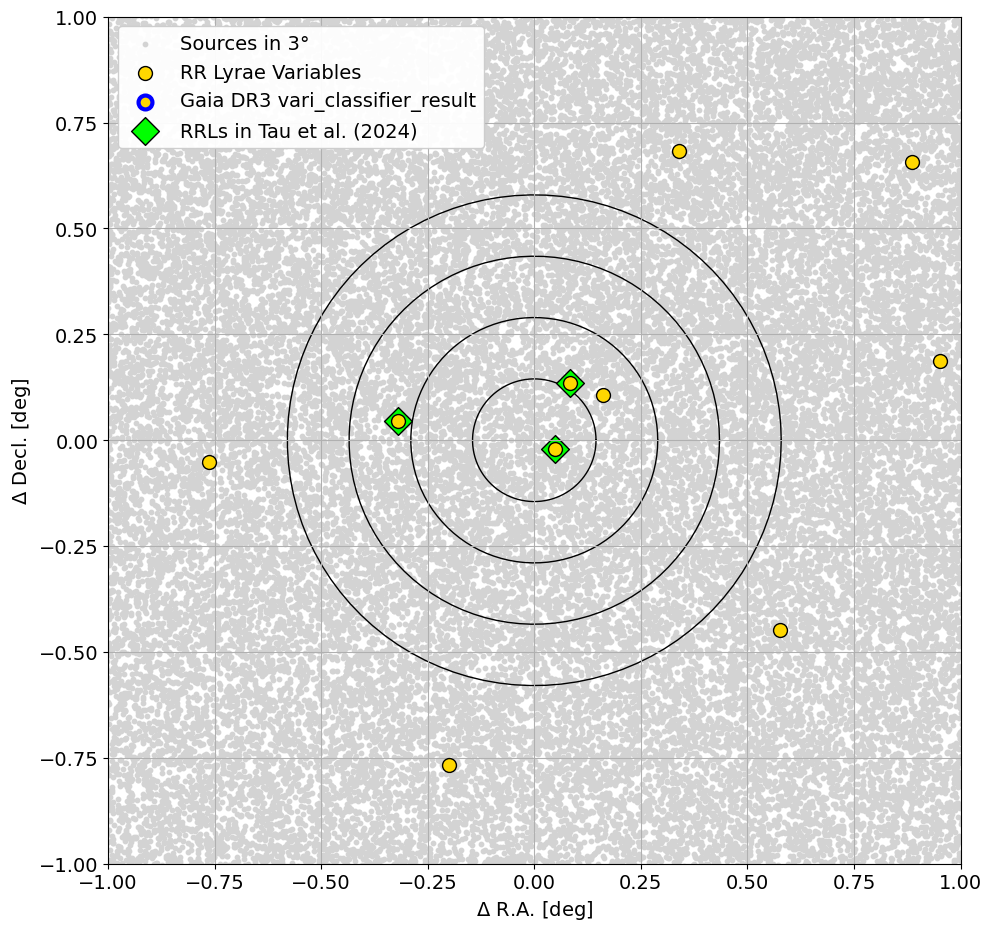

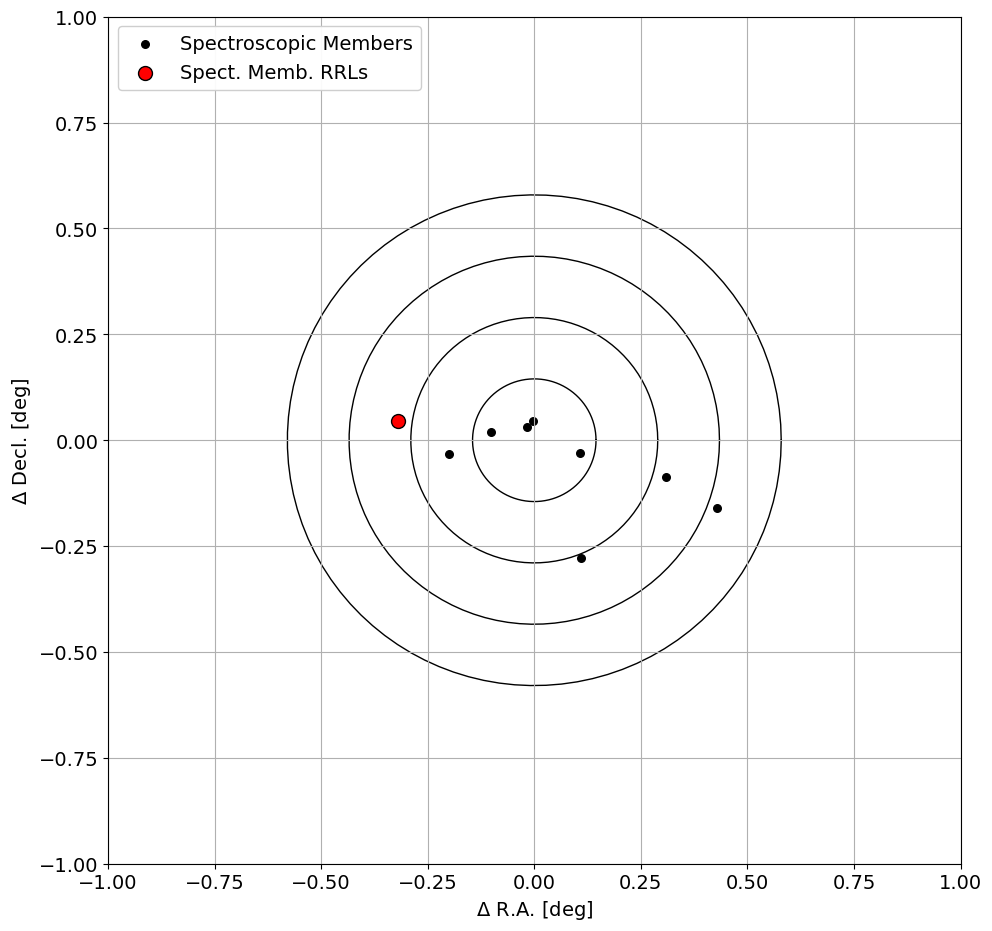

In [14]:
## Zoom in

t = np.linspace(0, 2*np.pi, 100)

plt.figure(figsize=(11,11))
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'$\Delta$ R.A. [deg]', fontsize=14)
plt.ylabel(r'$\Delta$ Decl. [deg]', fontsize=14)

plt.scatter(data['ra'] - center[0], data['dec'] - center[1], s=10, marker='o', c='lightgrey', label='Sources in 3°', zorder=0)
plt.scatter(rr['ra'] - center[0], rr['dec'] - center[1], s=100, marker='o', color='gold', edgecolor='k', label='RR Lyrae Variables', zorder=2)
plt.scatter(add_class_rr['ra'] - center[0], add_class_rr['dec'] - center[1], s=100, marker='o', color='gold', edgecolor='blue', linewidth=3, label='Gaia DR3 vari_classifier_result', zorder=2)
plt.scatter(tau['ra'] - center[0], tau['dec'] - center[1], s=200, marker='D', c='lime', edgecolor='k', label='RRLs in Tau et al. (2024)', zorder=1)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*3*np.cos(t),r_half*3*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*4*np.cos(t),r_half*4*np.sin(t),c='k', linewidth=1, zorder=0)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)
plt.savefig('Plot/CarinaII/CarinaI_initial_map.png', bbox_inches='tight', pad_inches=0.1)
plt.show()


# Spectroscopic Members

plt.figure(figsize=(11,11))
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'$\Delta$ R.A. [deg]', fontsize=14)
plt.ylabel(r'$\Delta$ Decl. [deg]', fontsize=14)

plt.scatter(memb['ra'] - center[0], memb['dec'] - center[1], s=30, marker='o', c='black', edgecolor='k', label='Spectroscopic Members', zorder=1)
plt.scatter(memb_rr['ra'] - center[0], memb_rr['dec'] - center[1], s=100, marker='o', c='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=3)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*3*np.cos(t),r_half*3*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*4*np.cos(t),r_half*4*np.sin(t),c='k', linewidth=1, zorder=0)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)
plt.savefig('Plot/CarinaII/CarinaII_memb_map.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

### Colormap of RR Lyrae based on 'int_average_g'

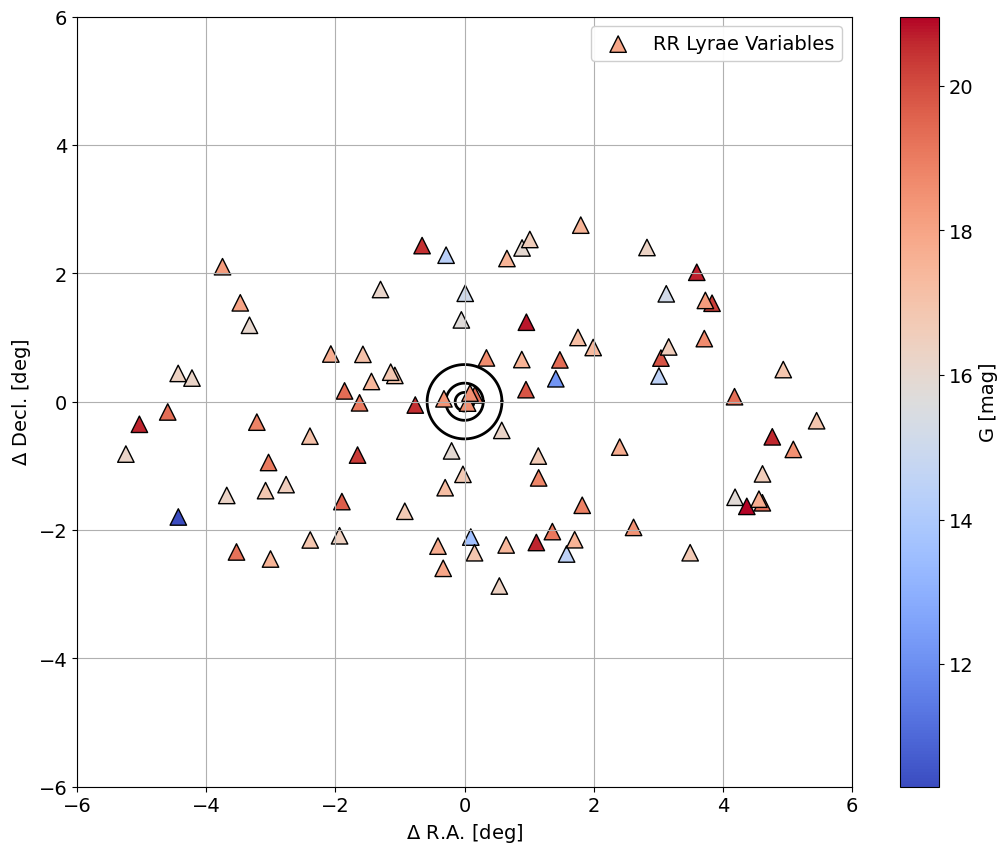

In [15]:
plt.figure(figsize=(12.5,10))
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'$\Delta$ R.A. [deg]', fontsize=14)
plt.ylabel(r'$\Delta$ Decl. [deg]', fontsize=14)

plt.scatter(rr['ra'] - center[0], rr['dec'] - center[1], c=rr['int_average_g'], cmap='coolwarm', s=140, marker='^', edgecolor='k', label='RR Lyrae Variables', zorder=1)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=2, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=2, zorder=0)
plt.plot(r_half*4*np.cos(t),r_half*4*np.sin(t),c='k', linewidth=2, zorder=0)

plt.legend(loc=1, fontsize=14, framealpha=0.95)
plt.grid(True)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)
cbar.set_label('G [mag]', fontsize=14)
plt.savefig('Plot/CarinaII/CarinaII_colormap.png', bbox_inches='tight', pad_inches=0)
plt.show()

## RR Lyrae selection through Proper Motions + PWZ

### Proper Motions

#### Errors on Proper Motions ([Gaia EDR3](https://doi.org/10.1051/0004-6361/202039657), table 3): comparison with Spectroscopic Members

In [16]:
# Cut at pm_error = 0.5

print('Initial RR Lyrae: ', len(rr))

mask_pm05 = ((rr['pmra_error'] < 0.5) | (rr['pmdec_error'] < 0.5))
pm05 = rr[mask_pm05]

print('RR Lyrae with pmra_error and pmdec_error < 0.5: ', len(pm05))

if len(pm05) < len(rr) :
    print(str(len(rr) - len(pm05)) + ' RR Lyrae removed:')
    print(rr[~mask_pm05]['source_id'])
    
#rr[~mask_pm05].to_csv('Output/CarinaII/CarinaII_pmerr05.csv', index=False)

Initial RR Lyrae:  90
RR Lyrae with pmra_error and pmdec_error < 0.5:  80
10 RR Lyrae removed:
1     5293936904769171712
12    5294248891196367104
20    5292723765486144512
48    5293806883224347904
54    5488780570056679552
58    5294029366825303296
62    5487666833493107328
65    5485882600999857280
86    5296028622562119040
87    5295956570191055744
Name: source_id, dtype: int64


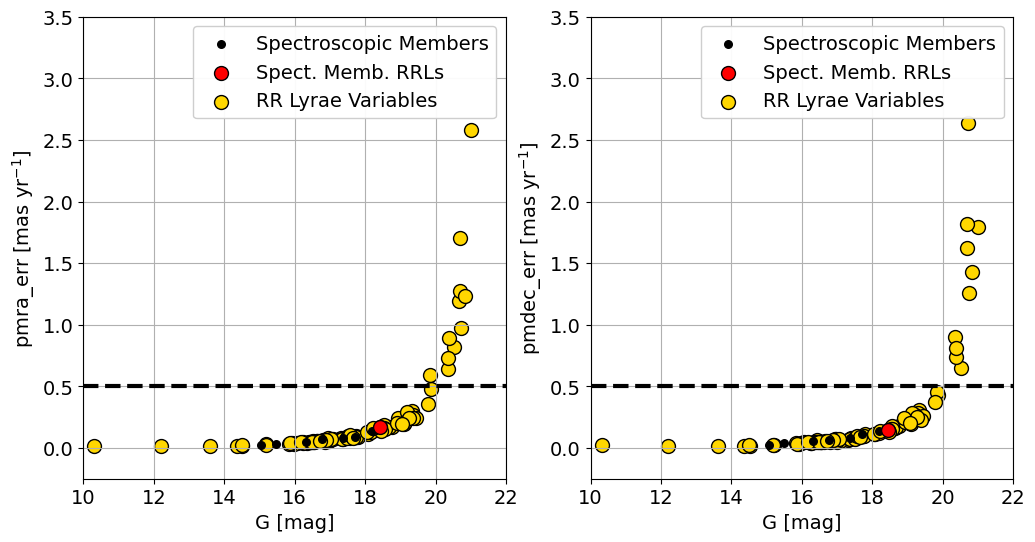

In [17]:
pm1, (pmraerr1, pmdecerr1) = plt.subplots(1, 2, figsize=(12,6))

# PM RA with Spectroscopic Members

pmraerr1.set_xlim(10,22)
pmraerr1.set_ylim(-0.25,3.5)
pmraerr1.tick_params(labelsize=14)
pmraerr1.set_xlabel('G [mag]', fontsize=14)
pmraerr1.set_ylabel(r'pmra_err [mas yr$^{-1}$]', fontsize=14)
pmraerr1.scatter(memb['phot_g_mean_mag'], memb['pmra_error'], s=30, marker='o', color='k', edgecolor='k', label='Spectroscopic Members', zorder=2)
pmraerr1.scatter(memb_rr['phot_g_mean_mag'], memb_rr['pmra_error'], s=100, marker='o', color='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=2)
pmraerr1.scatter(rr['phot_g_mean_mag'], rr['pmra_error'], s=100, marker='o', color='gold', edgecolor='k', label='RR Lyrae Variables')
pmraerr1.plot([10,22], [0.5,0.5], color='k', linewidth=3, linestyle='dashed')
pmraerr1.legend(loc=1, fontsize=14, framealpha=0.95)
pmraerr1.grid(True)

## PM DEC with Spectroscopic Members

pmdecerr1.set_xlim(10,22)
pmdecerr1.set_ylim(-0.25,3.5)
pmdecerr1.tick_params(labelsize=14)
pmdecerr1.set_xlabel('G [mag]', fontsize=14)
pmdecerr1.set_ylabel(r'pmdec_err [mas yr$^{-1}$]', fontsize=14)
pmdecerr1.scatter(memb['phot_g_mean_mag'], memb['pmdec_error'], s=30, marker='o', color='k', edgecolor='k', label='Spectroscopic Members', zorder=2)
pmdecerr1.scatter(memb_rr['phot_g_mean_mag'], memb_rr['pmdec_error'], s=100, marker='o', color='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=2)
pmdecerr1.scatter(rr['phot_g_mean_mag'], rr['pmdec_error'], s=100, marker='o', color='gold', edgecolor='k', label='RR Lyrae Variables')
pmdecerr1.plot([10,22], [0.5,0.5], color='k', linewidth=3, linestyle='dashed')
pmdecerr1.legend(loc=1, fontsize=14, framealpha=0.95)
pmdecerr1.grid(True)

plt.savefig('Plot/CarinaII/CarinaII_pmerr.png', bbox_inches='tight', pad_inches=0)
plt.show()

In [18]:
# pm_error < 0.5 cut

rr = rr[mask_pm05]

#### Histograms

In [19]:
## Gaussian of Data

mask3 = ((data_4rh['pmra'] > -20) & (data_4rh['pmra'] < 20) & (data_4rh['pmdec'] > -20) & (data_4rh['pmdec'] < 20))
data_mask3 = data_4rh[mask3]

mu_ra, std_ra = norm.fit(data_mask3['pmra'])
mu_dec, std_dec = norm.fit(data_mask3['pmdec'])

x = np.linspace(-50, 50, 1000)
p_ra = norm.pdf(x, mu_ra, std_ra)
p_dec = norm.pdf(x, mu_dec, std_dec)


## Gaussian of RR Lyrae in 3°

mu_rr_ra, std_rr_ra = norm.fit(rr['pmra'])
mu_rr_dec, std_rr_dec = norm.fit(rr['pmdec'])

x_rr = np.linspace(-50, 50, 1000)
p_rr_ra = norm.pdf(x_rr, mu_rr_ra, std_rr_ra)
p_rr_dec = norm.pdf(x_rr, mu_rr_dec, std_rr_dec)


## Gaussian of Sectroscopic Members

memb_mask = memb

mu_memb_ra, std_memb_ra = norm.fit(memb_mask['pmra'])
mu_memb_dec, std_memb_dec = norm.fit(memb_mask['pmdec'])

x_memb = np.linspace(-20, 20, 1000)
p_memb_ra = norm.pdf(x_memb, mu_memb_ra, std_memb_ra)
p_memb_dec = norm.pdf(x_memb, mu_memb_dec, std_memb_dec)


## Proper Motion centers

center_mymemb = np.array(object=(mu_memb_ra, mu_memb_dec))
err_mymemb = np.array(object=(std_memb_ra, std_memb_dec))

In [20]:
array = {'name': ['sources_ra', 'sources_dec', 'rr_ra', 'rr_dec', 'memb_ra', 'memb_dec'],
         'mu': [mu_ra, mu_dec, mu_rr_ra, mu_rr_dec, mu_memb_ra, mu_memb_dec],
         'std': [std_ra, std_dec, std_rr_ra, std_rr_dec, std_memb_ra, std_memb_dec]}

array_mu_std = pd.DataFrame(array)

print(array_mu_std)

array_mu_std.to_csv('Output/CarinaII/CarinaII_mu_std.csv', index=False)

          name        mu       std
0   sources_ra -1.886609  3.631222
1  sources_dec  5.099444  4.758008
2        rr_ra  0.668815  1.483913
3       rr_dec  0.850327  2.482804
4      memb_ra  1.886988  0.059321
5     memb_dec  0.149220  0.062713


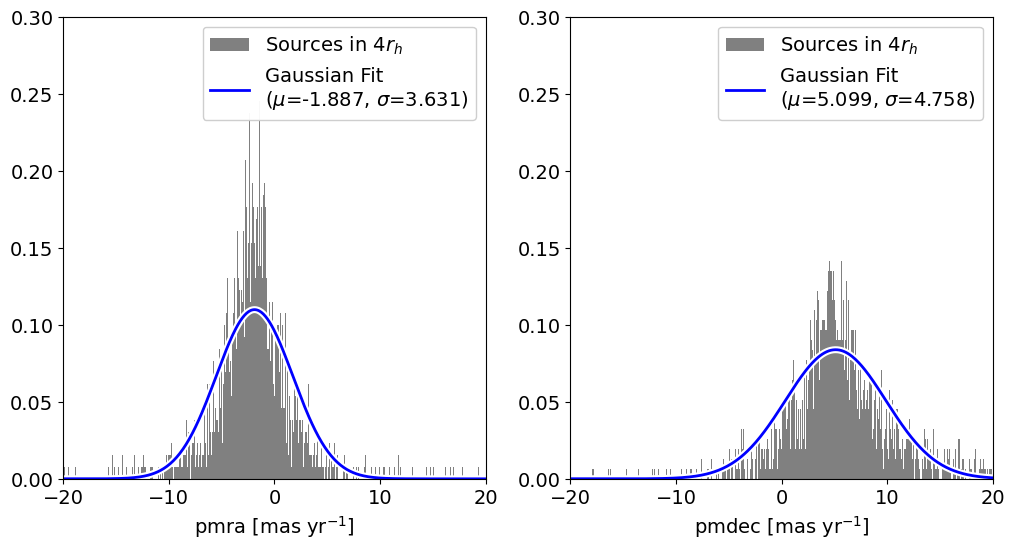

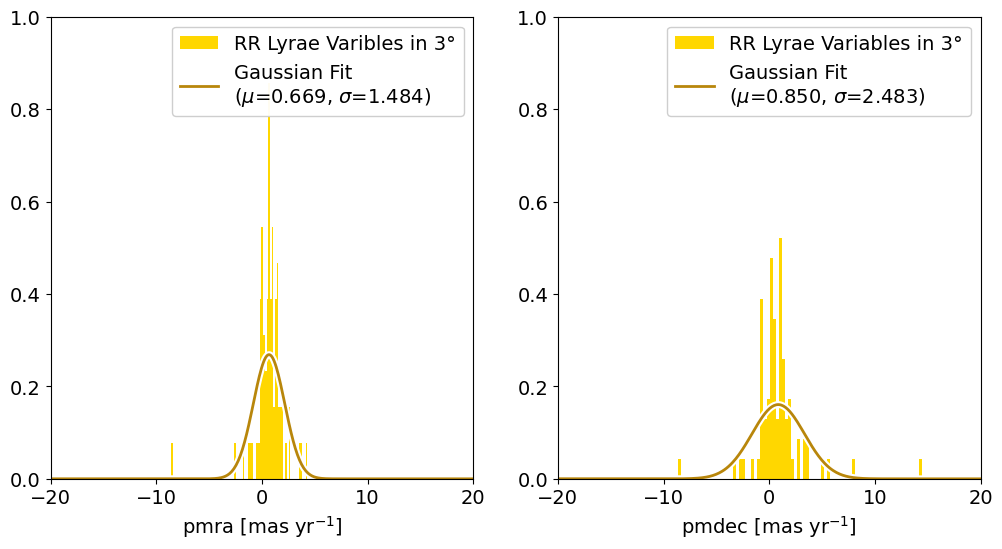

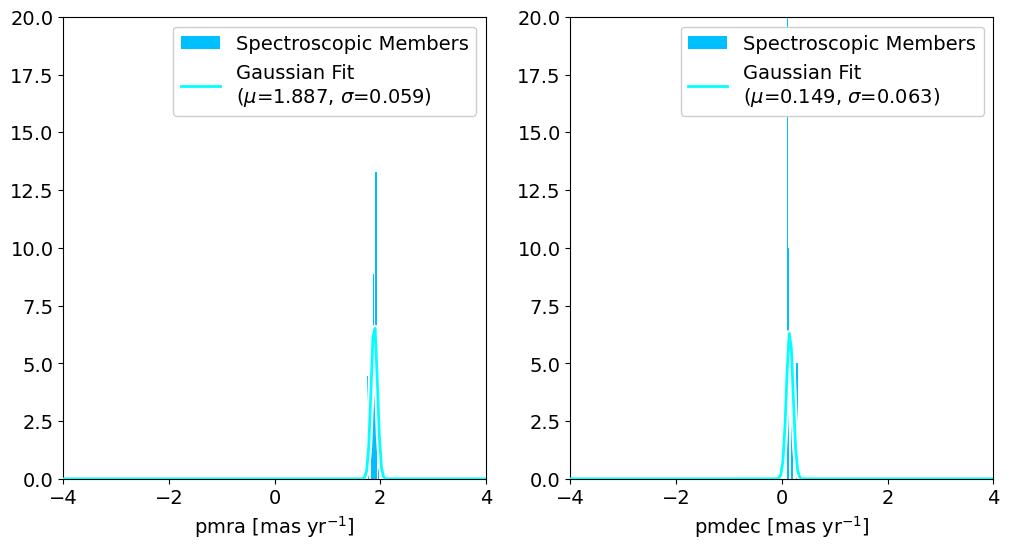

In [21]:
## Histograms

# Sources in 4*r_h

pm1, (pmra1, pmdec1) = plt.subplots(1, 2, figsize=(12,6))

pmra1.set_xlim(-20,20)
pmra1.set_ylim(0,0.3)
pmra1.tick_params(labelsize=14)
pmra1.set_xlabel(r'pmra [mas yr$^{-1}$]', fontsize=14)
pmra1.hist(data_4rh['pmra'], bins=len(data_4rh), density=True, label=r'Sources in 4$r_h$', color='grey')
pmra1.plot(x, p_ra, c='white', linewidth=5)
pmra1.plot(x, p_ra, c='blue', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_ra) + ', $\sigma$=' + '{:.3f}'.format(std_ra) + ')')
pmra1.legend(loc=1, fontsize=14, framealpha=0.95)

pmdec1.set_xlim(-20,20)
pmdec1.set_ylim(0,0.3)
pmdec1.tick_params(labelsize=14)
pmdec1.set_xlabel(r'pmdec [mas yr$^{-1}$]', fontsize=14)
pmdec1.hist(data_4rh['pmdec'], bins=len(data_4rh), density=True, label=r'Sources in 4$r_h$', color='grey')
pmdec1.plot(x, p_dec, c='white', linewidth=5)
pmdec1.plot(x, p_dec, c='blue', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_dec) + ', $\sigma$=' + '{:.3f}'.format(std_dec) + ')')
pmdec1.legend(loc=1, fontsize=14, framealpha=0.95)

plt.savefig('Plot/CarinaII/CarinaII_pm_sources.png', bbox_inches='tight', pad_inches=0)
plt.show()


# RR Lyrae in 3°

pm1, (pmra1, pmdec1) = plt.subplots(1, 2, figsize=(12,6))

pmra1.set_xlim(-20,20)
pmra1.set_ylim(0,1)
pmra1.tick_params(labelsize=14)
pmra1.set_xlabel(r'pmra [mas yr$^{-1}$]', fontsize=14)
pmra1.hist(rr['pmra'], bins=len(rr), density=True, label=r'RR Lyrae Varibles in 3°', color='gold')
pmra1.plot(x_rr, p_rr_ra, c='white', linewidth=5)
pmra1.plot(x_rr, p_rr_ra, c='darkgoldenrod', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_rr_ra) + ', $\sigma$=' + '{:.3f}'.format(std_rr_ra) + ')')
pmra1.legend(loc=1, fontsize=14, framealpha=0.95)

pmdec1.set_xlim(-20,20)
pmdec1.set_ylim(0,1)
pmdec1.tick_params(labelsize=14)
pmdec1.set_xlabel(r'pmdec [mas yr$^{-1}$]', fontsize=14)
pmdec1.hist(rr['pmdec'], bins=len(rr), density=True, label=r'RR Lyrae Variables in 3°', color='gold')
pmdec1.plot(x_rr, p_rr_dec, c='white', linewidth=5)
pmdec1.plot(x_rr, p_rr_dec, c='darkgoldenrod', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_rr_dec) + ', $\sigma$=' + '{:.3f}'.format(std_rr_dec) + ')')
pmdec1.legend(loc=1, fontsize=14, framealpha=0.95)

plt.savefig('Plot/CarinaII/CarinaII_pm_rr.png', bbox_inches='tight', pad_inches=0)
plt.show()


# With Spectroscopic Members

pm2, (pmra2, pmdec2) = plt.subplots(1, 2, figsize=(12,6))

pmra2.set_xlim(-4,4)
pmra2.set_ylim(0,20)
pmra2.tick_params(labelsize=14)
pmra2.set_xlabel(r'pmra [mas yr$^{-1}$]', fontsize=14)
pmra2.hist(memb['pmra'], bins=len(memb), density=True, label='Spectroscopic Members', color='deepskyblue', zorder=0)
pmra2.plot(x_memb, p_memb_ra, c='white', linewidth=5)
pmra2.plot(x_memb, p_memb_ra, c='cyan', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_memb_ra) + ', $\sigma$=' + '{:.3f}'.format(std_memb_ra) + ')', zorder=3)
pmra2.legend(loc=1, fontsize=14, framealpha=0.95)

pmdec2.set_xlim(-4,4)
pmdec2.set_ylim(0,20)
pmdec2.tick_params(labelsize=14)
pmdec2.set_xlabel(r'pmdec [mas yr$^{-1}$]', fontsize=14)
pmdec2.hist(memb['pmdec'], bins=len(memb), density=True, label='Spectroscopic Members', color='deepskyblue', zorder=0)
pmdec2.plot(x_memb, p_memb_dec, c='white', linewidth=5)
pmdec2.plot(x_memb, p_memb_dec, c='cyan', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_memb_dec) + ', $\sigma$=' + '{:.3f}'.format(std_memb_dec) + ')', zorder=3)
pmdec2.legend(loc=1, fontsize=14, framealpha=0.95)

plt.savefig('Plot/CarinaII/CarinaII_pm_memb.png', bbox_inches='tight', pad_inches=0)
plt.show()

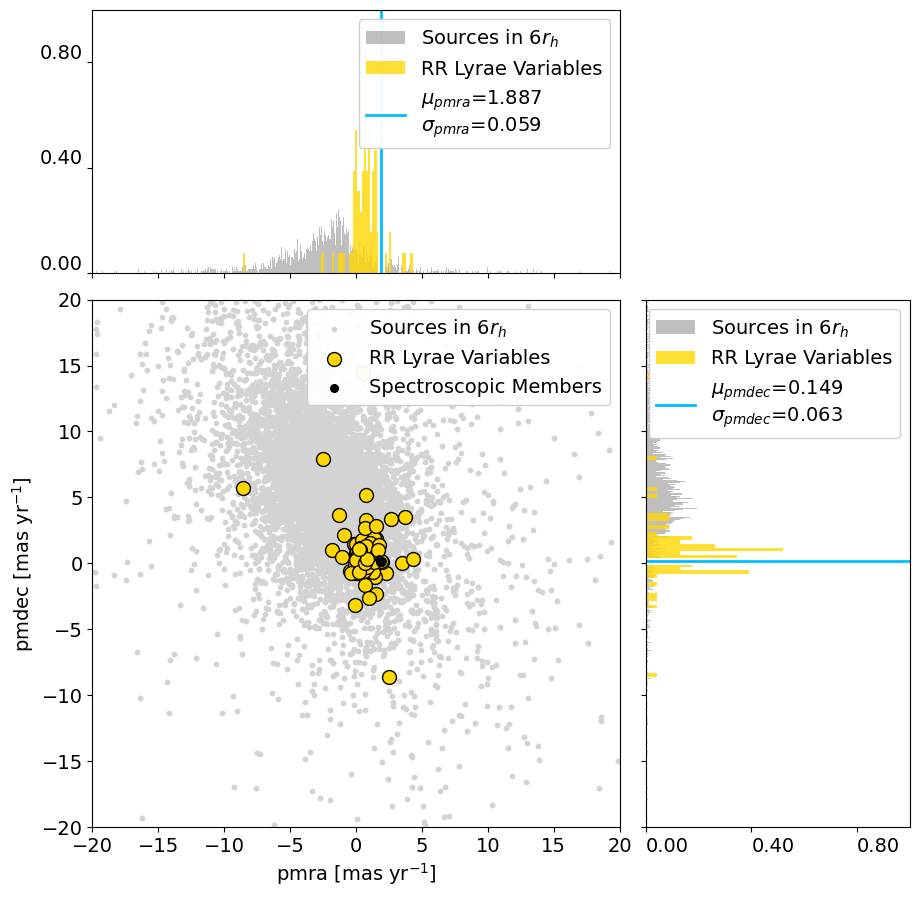

In [22]:
## PM FOR PAPER

pm3 = plt.figure(layout='tight', figsize=(11,11))
ax3 = pm3.add_subplot()

ax3.set_aspect('equal')

ax3_histx = ax3.inset_axes([0, 1.05, 1, 0.5], sharex=ax3)
ax3_histy = ax3.inset_axes([1.05, 0, 0.5, 1], sharey=ax3)

scatter_hist(data_4rh['pmra'], data_4rh['pmdec'], rr['pmra'], rr['pmdec'], ax3, ax3_histx, ax3_histy, center_mymemb, err_mymemb)

ax3.scatter(memb['pmra'], memb['pmdec'], s=30, color='black', edgecolor='k', label='Spectroscopic Members', zorder=5)

ax3.legend(loc=1, fontsize=14, framealpha=0.95)

plt.setp(ax3_histy.get_xticklabels(), ha='left')
plt.setp(ax3_histx.get_yticklabels(), va='bottom')

plt.savefig('Plot/CarinaII/CarinaII_paper01.png', bbox_inches='tight', pad_inches=0.1)
plt.show()


In [23]:
#--- Proper Motions of Additional Classified ---#

print('Proper Motions of Additional Classified')

## Gaussian of Data

class_mu_ra, class_std_ra = norm.fit(add_class_rr['pmra'])
class_mu_dec, class_std_dec = norm.fit(add_class_rr['pmdec'])

print('mu_ra: ', class_mu_ra, '; std_ra: ', class_std_ra)
print('mu_dec: ', class_mu_dec, '; std_dec: ', class_std_dec)

class_x = np.linspace(-50, 50, 1000)
class_p_ra = norm.pdf(class_x, class_mu_ra, class_std_ra)
class_p_dec = norm.pdf(class_x, class_mu_dec, class_std_dec)


Proper Motions of Additional Classified
mu_ra:  -0.4074033077580085 ; std_ra:  3.077340973749877
mu_dec:  2.9925145711878463 ; std_dec:  2.9845228527700467


### Sources within 3$\sigma$ of mean proper motions (w.r.t. Spectroscopic Members)

In [24]:
## Sources in 3°

mask4 = (data['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (data['pmra'] >= mu_memb_ra - 3*std_memb_ra)

data_final = data[mask4]

mask4 = (data_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (data_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

data_final = data_final[mask4]

print('Sources within 3sigma of mean proper motions in 3°: ' + str(len(data_final)))


## Sources in 4*r_h

mask4 = (data_4rh['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (data_4rh['pmra'] >= mu_memb_ra - 3*std_memb_ra)

data_4rh_final = data_4rh[mask4]

mask4 = (data_4rh_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (data_4rh_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

data_4rh_final = data_4rh_final[mask4]

print('Sources within 3sigma of mean proper motions in 4r_h: ' + str(len(data_4rh_final)))


## RR Lyrae in 3°

mask5 = (rr['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (rr['pmra'] >= mu_memb_ra - 3*std_memb_ra)

rr_final = rr[mask5]

mask5 = (rr_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (rr_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

rr_final = rr_final[mask5]

print('RR Lyrae within 3sigma of mean proper motions in 3°: ' + str(len(rr_final)))


## RR Lyrae in 4*r_h

mask6 = (rr_4rh['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (rr_4rh['pmra'] >= mu_memb_ra - 3*std_memb_ra)

rr_4rh_final = rr_4rh[mask6]

mask6 = (rr_4rh_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (rr_4rh_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

rr_4rh_final = rr_4rh_final[mask6]

print('RR Lyrae within 3sigma of mean proper motions in 4r_h: ' + str(len(rr_4rh_final)))


## RR Lyrae Classified in 3°

mask7 = (add_class_rr['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (add_class_rr['pmra'] >= mu_memb_ra - 3*std_memb_ra)

add_class_rr_final = add_class_rr[mask7]

mask7 = (add_class_rr_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (add_class_rr_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

add_class_rr_final = add_class_rr_final[mask7]

print('Classified RR Lyrae within 3sigma of mean proper motions in 3°: ' + str(len(add_class_rr_final)))

Sources within 3sigma of mean proper motions in 3°: 277
Sources within 3sigma of mean proper motions in 4r_h: 30
RR Lyrae within 3sigma of mean proper motions in 3°: 3
RR Lyrae within 3sigma of mean proper motions in 4r_h: 3
Classified RR Lyrae within 3sigma of mean proper motions in 3°: 0


### Period-Wesenheit-Metallicity Relation

In [25]:
w_mag_final = wesen(rr_final['int_average_g'], rr_final['phot_bp_mean_mag'], rr_final['phot_rp_mean_mag'])
w_mag_error_final = wesen_err(rr_final['int_average_g_error'], rr_final['phot_bp_mean_mag_error'], rr_final['phot_rp_mean_mag_error'])
w_mag_tau = wesen(tau_rr['int_average_g'], tau_rr['phot_bp_mean_mag'], tau_rr['phot_rp_mean_mag'])
w_mag_memb_rr = wesen(memb_rr['int_average_g'], memb_rr['phot_bp_mean_mag'], memb_rr['phot_rp_mean_mag'])


## Garofalo et al. 2022: intrinsic dispersion of 0.09 ± 0.01 mag

w_sigma = 0.09


## Period

period_final = np.log10(rr_final['pf'])
period_final[np.isnan(period_final)] = np.log10(rr_final['p1_o'][np.isnan(period_final)]) + 0.127



## Info. from Vivas et al. 2020

# Distance Module

mu0 = float(- 5 + 5 * np.log10(vivas['distance'] * 1000.0))

print('Distance Module: ' + str(mu0))


# Iron Abundance

fe = float(vivas['fe_h'])

print('Iron Abundance: ' + str(fe))


## General Wesenheit Relation

pw_line_final = pw(period_final, fe, mu0)


# Generic only for plot

t = np.linspace(-0.5, 0, 100)
pw_generic = pw(t, fe, mu0)


## RR Lyrae in 3sigma of PW

rr_pw_final = rr_final.copy()
rr_pw_final.insert(len(rr_pw_final.columns), 'w_mag', w_mag_final)
rr_pw_final.insert(len(rr_pw_final.columns), 'w_period', period_final)
rr_pw_final.insert(len(rr_pw_final.columns), 'pw_line', pw_line_final)

mask_pw_final = ((w_mag_final <= pw_line_final + 3*w_sigma) & (w_mag_final >= pw_line_final - 3*w_sigma) |
           (w_mag_final + w_mag_error_final <= pw_line_final + 3*w_sigma) & (w_mag_final + w_mag_error_final >= pw_line_final - 3*w_sigma) |
           (w_mag_final - w_mag_error_final <= pw_line_final + 3*w_sigma) & (w_mag_final - w_mag_error_final >= pw_line_final - 3*w_sigma))

rr_pw_final = rr_pw_final[mask_pw_final]

print('RR Lyrae within 3sigma of Wesenheit Relation: ' + str(len(rr_pw_final)))

Distance Module: 17.8643580110024
Iron Abundance: -2.44
RR Lyrae within 3sigma of Wesenheit Relation: 3


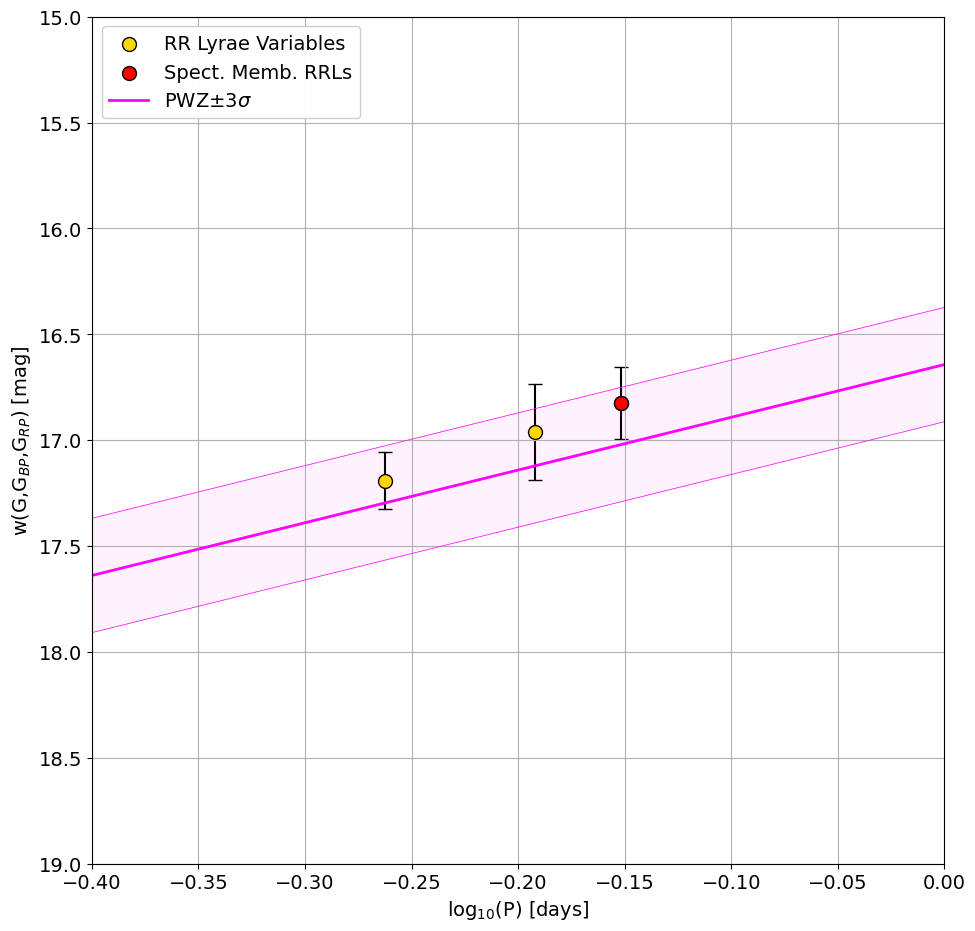

In [26]:
## PWZ

plt.figure(figsize=(11,11))
plt.xlim(-0.4,0)
plt.ylim(19,15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r'log$_{10}$(P) [days]', fontsize=14)
plt.ylabel(r'w(G,G$_{BP}$,G$_{RP}$) [mag]', fontsize=14)


# All RR Lyrae

plt.scatter(np.log10(rr_final['pf']), w_mag_final, c='gold', edgecolor='k', marker='o', s=100, label='RR Lyrae Variables', zorder=1)
plt.scatter(np.log10(rr_final['p1_o'])+0.127, w_mag_final, c='gold', edgecolor='k', marker='o', s=100, zorder=1) # Fundamentalisation
plt.errorbar(np.log10(rr_final['pf']), w_mag_final, yerr=w_mag_error_final, fmt='o', capsize=5, color='k', zorder=0)
plt.errorbar(np.log10(rr_final['p1_o'])+0.127, w_mag_final, yerr=w_mag_error_final, fmt='o', capsize=5, color='k', zorder=0)

plt.scatter(np.log10(memb_rr['pf']), w_mag_memb_rr, color='red', edgecolor='k', marker='o', s=100, label='Spect. Memb. RRLs', zorder=2)
plt.scatter(np.log10(memb_rr['p1_o'])+0.127, w_mag_memb_rr, color='red', edgecolor='k', marker='o', s=100, zorder=2)


# Intrinsic dispersion

plt.plot(t, pw_generic, c='magenta', linewidth=2, label=r'PWZ$\pm 3 \sigma$', linestyle = 'solid')
plt.plot(t, pw_generic + 3*w_sigma, c='magenta', linewidth=0.5, linestyle = 'solid')
plt.plot(t, pw_generic - 3*w_sigma, c='magenta', linewidth=0.5, linestyle = 'solid')
plt.fill_between(t, pw_generic + 3*w_sigma, pw_generic - 3*w_sigma, alpha=0.05, color='magenta', zorder=0)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)
plt.savefig('Plot/CarinaII/CarinaI_pwz.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

### Color-Magnitude Diagram

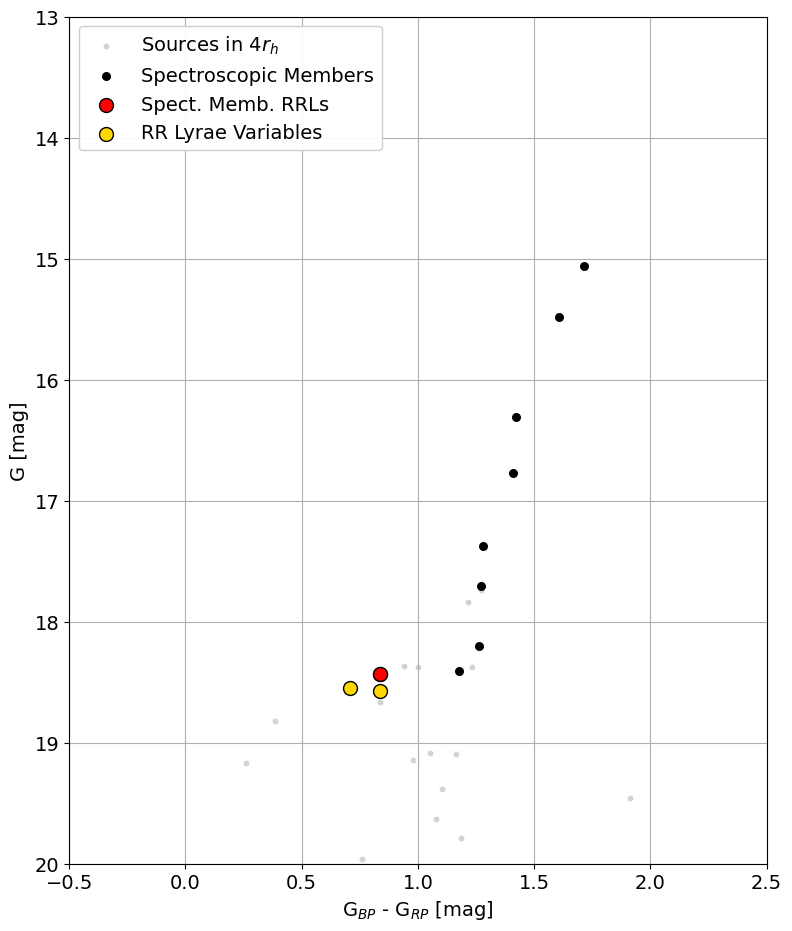

In [27]:
## CMD

plt.figure(figsize=(9,11))
plt.xlim(-0.5,2.5)
plt.ylim(20,13)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r'G$_{BP}$ - G$_{RP}$ [mag]', fontsize=14)
plt.ylabel('G [mag]', fontsize=14)

plt.scatter(data_4rh_final['phot_bp_mean_mag'] - data_4rh_final['phot_rp_mean_mag'], data_4rh_final['phot_g_mean_mag'], s=10, c='lightgrey', marker='o', label=r'Sources in 4$r_h$', zorder=0)
plt.scatter(memb['phot_bp_mean_mag'] - memb['phot_rp_mean_mag'], memb['phot_g_mean_mag'], s=30, marker='o', color='k', label='Spectroscopic Members', zorder=1)
plt.scatter(memb_rr['phot_bp_mean_mag'] - memb_rr['phot_rp_mean_mag'], memb_rr['int_average_g'], s=100, marker='o', color='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=3)
plt.scatter(rr_pw_final['phot_bp_mean_mag'] - rr_pw_final['phot_rp_mean_mag'], rr_pw_final['int_average_g'], s=100, marker='o', edgecolor='k', color='gold', label=r'RR Lyrae Variables', zorder=2)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)
plt.savefig('Plot/CarinaII/CarinaII_paper02.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

### Map: Spectroscopic Members and RR Lyrae in 3$\sigma$ of PWZ

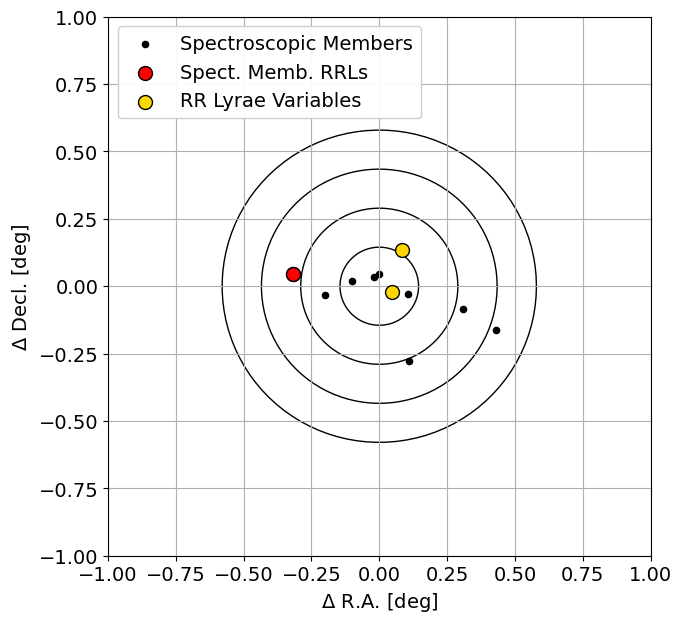

In [28]:
## Final map

t = np.linspace(0, 2*np.pi, 100)

plt.figure(figsize=(7,7))
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'$\Delta$ R.A. [deg]', fontsize=14)
plt.ylabel(r'$\Delta$ Decl. [deg]', fontsize=14)

plt.scatter(memb['ra'] - center[0], memb['dec'] - center[1], s=20, marker='o', c='black', edgecolor='k', label='Spectroscopic Members', zorder=1)
plt.scatter(memb_rr['ra'] - center[0], memb_rr['dec'] - center[1], s=100, marker='o', c='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=3)
plt.scatter(rr_pw_final['ra']- center[0], rr_pw_final['dec']- center[1], s=100, marker='o', c='gold', edgecolor='k', label='RR Lyrae Variables', zorder=2)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*3*np.cos(t),r_half*3*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*4*np.cos(t),r_half*4*np.sin(t),c='k', linewidth=1, zorder=0)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)

plt.savefig('Plot/CarinaII/CarinaII_final_map.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

## File saving

In [29]:
# RR Lyrae in 3° after PM cut
#rr_final.to_csv('Output/CarinaII/CarinaII_rr_pm.csv', index=False)

# Final 3 RRLs in Carina II
print('Final member RR Lyrae: ' + str(len(rr_pw_final)))
rr_pw_final.to_csv('Output/CarinaII/CarinaII_rr_final.csv', index=False)

Final member RR Lyrae: 3


## Conclusions
- After Proper Motion and PWZ selections, we found 3 RRLs (the same as Tau 2024)
- There is a RRd in Carina II, but it does not pass the selections
- The Spectroscopic RRL member passes the PWZ selection
- There are no Sagittarius stream RRLs in this region of the sky